## Bloque 2 · Machine Learning con Spark ML
**Dataset:** Accidentalidad vial histórica — Bogotá D.C.  
**Variable objetivo:** `GRAVEDAD` (SOLO DAÑOS / CON HERIDOS / CON MUERTOS)  
**Estudiante:** Valentina Muñoz Palma
**Curso:** Machine Learning con PySpark y Docker · 2026-I

## cargar librerías

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import col, count, when

from pyspark.ml import Pipeline
from pyspark.ml.feature import (
    StringIndexer, OneHotEncoder, VectorAssembler,
    StandardScaler, PCA
)
from pyspark.ml.clustering import KMeans
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier
from pyspark.ml.evaluation import (
    MulticlassClassificationEvaluator,
    BinaryClassificationEvaluator
)
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

## Iniciar sesión de Spark

In [2]:
# ============================================================
# Iniciar sesión de Spark
# ============================================================
spark = SparkSession.builder \
    .appName("Bloque2_ML_ValentinaMunoz") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

print("Sesión de Spark activa de forma exitosa.")

Sesión de Spark activa de forma exitosa.


## Cargar el dataset limpio del Bloque 1

In [3]:
# ============================================================
# Cargamos el dataset limpio producido en el Bloque 1
# ============================================================
path_data = "../bloque1_eda/datos_limpios.csv"
df = spark.read.csv(path_data, header=True, inferSchema=True)

print(f"Total de registros: {df.count():,}")
print(f"Total de columnas : {len(df.columns)}")
df.printSchema()

Total de registros: 199,146
Total de columnas : 16
root
 |-- OBJECTID: integer (nullable = true)
 |-- FORMULARIO: string (nullable = true)
 |-- CODIGO_ACCIDENTE: integer (nullable = true)
 |-- ANO_OCURRENCIA_ACC: integer (nullable = true)
 |-- MES: integer (nullable = true)
 |-- DIA: integer (nullable = true)
 |-- HORA: integer (nullable = true)
 |-- DIRECCION: string (nullable = true)
 |-- GRAVEDAD: string (nullable = true)
 |-- CLASE_ACC: string (nullable = true)
 |-- LOCALIDAD: string (nullable = true)
 |-- LATITUD: double (nullable = true)
 |-- LONGITUD: double (nullable = true)
 |-- CIV: integer (nullable = true)
 |-- PK_CALZADA: integer (nullable = true)
 |-- FRANJA_HORARIA: string (nullable = true)



In [4]:
# ============================================================
# Verificar distribución de la variable objetivo GRAVEDAD
# Esto es relevante para la elección de métricas y la interpretación del modelo
# ============================================================
total = df.count()
print("--- Distribución de GRAVEDAD (variable objetivo) ---")
df.groupBy("GRAVEDAD").count() \
  .withColumn("Porcentaje%", F.round((col("count") / total) * 100, 2)) \
  .orderBy(F.desc("count")).show()

--- Distribución de GRAVEDAD (variable objetivo) ---
+-----------+------+-----------+
|   GRAVEDAD| count|Porcentaje%|
+-----------+------+-----------+
| SOLO DANOS|128207|      64.38|
|CON HERIDOS| 67700|       34.0|
|CON MUERTOS|  3239|       1.63|
+-----------+------+-----------+



## PARTE A · Preparación de datos

### Decisiones de diseño

**Features seleccionadas:**
- **Numéricas directas:** `HORA`, `MES`, `DIA`, `ANO_OCURRENCIA_ACC`, `LATITUD`, `LONGITUD`
- **Categóricas (requieren indexación):** `CLASE_ACC`, `LOCALIDAD`, `FRANJA_HORARIA`
- **Excluidas:** `OBJECTID`, `FORMULARIO`, `CODIGO_ACCIDENTE`, `DIRECCION` (identificadores sin valor predictivo), `CIV` y `PK_CALZADA` (19% de nulos en PK_CALZADA y baja interpretabilidad para el modelo).

**Scaler elegido:** `StandardScaler`  
Se elige StandardScaler (media 0, desviación estándar 1) sobre MinMaxScaler porque:
1. PCA y K-Means son sensibles a la magnitud de las variables, no a su rango acotado.
2. Variables como `LATITUD` y `LONGITUD` tienen distribuciones aproximadamente normales, donde estandarizar es más apropiado que escalar al rango [0,1].
3. MinMaxScaler es preferible cuando los datos tienen distribución uniforme acotada; aquí no es el caso.

### Tarea 7 · Pipeline de preparación con StringIndexer, OneHotEncoder y VectorAssembler

In [5]:
# ============================================================
# PIndexar la variable objetivo GRAVEDAD
# Spark ML requiere que el label sea numérico (Double)
# StringIndexer asigna 0 al valor más frecuente, 1 al siguiente, etc.
# => 0: SOLO DANOS, 1: CON HERIDOS, 2: CON MUERTOS
# ============================================================
indexer_label = StringIndexer(
    inputCol="GRAVEDAD",
    outputCol="label",
    handleInvalid="keep"
)

In [6]:

# ============================================================
# Indexar variables categóricas (texto → número)
# StringIndexer convierte cada categoría en un índice entero
# ============================================================
cols_categoricas = ["CLASE_ACC", "LOCALIDAD", "FRANJA_HORARIA"]

indexers = [
    StringIndexer(
        inputCol=col_cat,
        outputCol=col_cat + "_idx",
        handleInvalid="keep"
    )
    for col_cat in cols_categoricas
]


In [7]:
# ============================================================
# OneHotEncoder sobre los índices categóricos
# Evita que el modelo interprete los índices como ordinales
# ============================================================
encoder = OneHotEncoder(
    inputCols=[col_cat + "_idx" for col_cat in cols_categoricas],
    outputCols=[col_cat + "_ohe" for col_cat in cols_categoricas],
    handleInvalid="keep"
)



In [8]:
# ============================================================
# VectorAssembler — unir todas las features en un vector
# ============================================================
cols_numericas = ["HORA", "MES", "DIA", "ANO_OCURRENCIA_ACC", "LATITUD", "LONGITUD"]
cols_ohe       = [col_cat + "_ohe" for col_cat in cols_categoricas]

assembler = VectorAssembler(
    inputCols=cols_numericas + cols_ohe,
    outputCol="features_raw",
    handleInvalid="keep"
)

print("Etapas del pipeline de preparación definidas correctamente.")
print(f"   Features numéricas : {cols_numericas}")

Etapas del pipeline de preparación definidas correctamente.
   Features numéricas : ['HORA', 'MES', 'DIA', 'ANO_OCURRENCIA_ACC', 'LATITUD', 'LONGITUD']


### Tarea 8 · Normalización con StandardScaler

In [9]:
# ============================================================
# StandardScaler: estandariza cada feature a media=0 y std=1
# withMean=False porque el vector incluye columnas OHE (sparse)
# y calcular la media en vectores sparse es costoso en memoria
# ============================================================
scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features_scaled",
    withStd=True,
    withMean=False
)

In [10]:
# ============================================================
# Construimos el pipeline de preparación y lo ajustamos
# ============================================================
pipeline_prep = Pipeline(stages=[indexer_label] + indexers + [encoder, assembler, scaler])
modelo_prep   = pipeline_prep.fit(df)
df_prep       = modelo_prep.transform(df)

print("Pipeline de preparación ajustado y aplicado.")
print(f"   Columnas en el DataFrame preparado: {len(df_prep.columns)}")
df_prep.select("GRAVEDAD", "label", "features_scaled").show(3, truncate=False)

Pipeline de preparación ajustado y aplicado.
   Columnas en el DataFrame preparado: 25
+-----------+-----+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|GRAVEDAD   |label|features_scaled                                                                                                                                                                                       |
+-----------+-----+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|SOLO DANOS |0.0  |(39,[0,1,2,3,4,5,6,15,35],[0.9288666871732615,1.7661894229648607,1.3659898378273858,1087.2899950360677,81.53577569573886,-1847.72058712723,2.8621569935239943,3.260850222035329,2.001584101497602])   |
|CON HERIDOS|1.0  |(39,[0,1,2,3,4,5,1

## PARTE B · Aprendizaje no supervisado

### Tarea 9 · PCA — varianza explicada por componente

Aplicamos PCA sobre el vector estandarizado para reducir la dimensionalidad antes de K-Means. PCA requiere que las features estén escaladas para que ninguna variable domine por tener mayor magnitud.

In [ ]:
# ============================================================
# Aplicamos PCA con k=10 para explorar la varianza explicada
# ============================================================
pca_explorador = PCA(k=10, inputCol="features_scaled", outputCol="pca_features")
modelo_pca     = pca_explorador.fit(df_prep)

# Extraemos la varianza explicada por cada componente principal
varianza_explicada    = modelo_pca.explainedVariance.toArray()
varianza_acumulada    = np.cumsum(varianza_explicada)

print("--- Varianza explicada por cada componente principal ---")
print(f"{'PC':<6} {'Varianza Individual':>22} {'Varianza Acumulada':>20}")
print("-" * 50)
for i, (ind, acum) in enumerate(zip(varianza_explicada, varianza_acumulada)):
    print(f"PC{i+1:<4} {ind:>22.4f} {acum:>20.4f}")

--- Varianza explicada por cada componente principal ---
PC        Varianza Individual   Varianza Acumulada
--------------------------------------------------
PC1                    0.0705               0.0705
PC2                    0.0541               0.1246
PC3                    0.0500               0.1746
PC4                    0.0450               0.2196
PC5                    0.0409               0.2604
PC6                    0.0303               0.2908
PC7                    0.0302               0.3210
PC8                    0.0301               0.3511
PC9                    0.0296               0.3807
PC10                   0.0290               0.4096


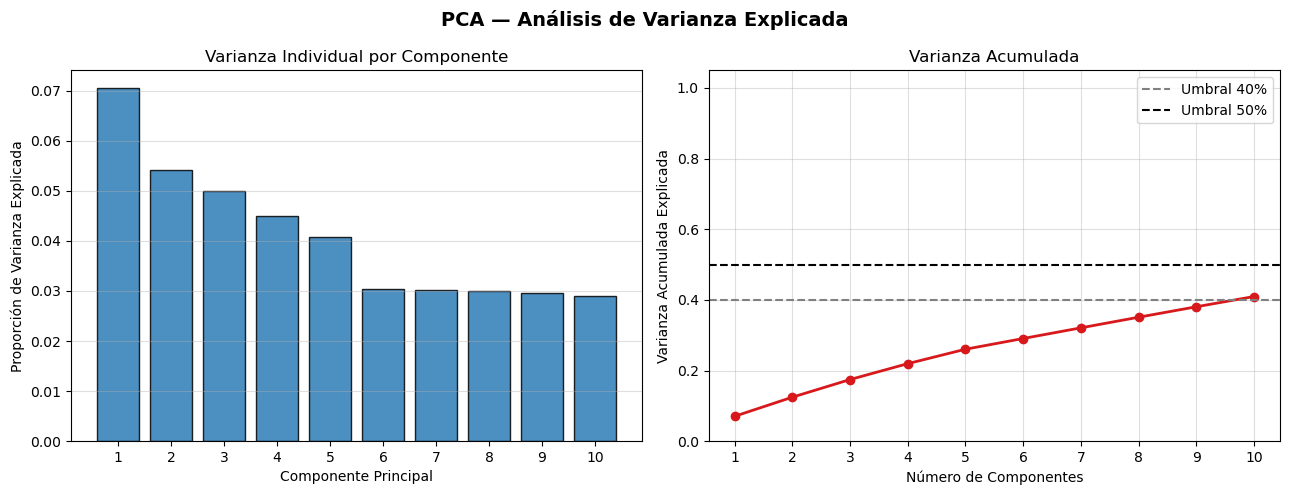

Gráfico guardado como graficos/pca_varianza_explicada.png


In [ ]:
# ============================================================
# Gráfico: varianza explicada acumulada por componente
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("PCA — Análisis de Varianza Explicada", fontsize=14, fontweight="bold")

componentes = range(1, len(varianza_explicada) + 1)

# Barras: varianza individual
axes[0].bar(componentes, varianza_explicada, color="#2c7bb6", alpha=0.85, edgecolor="black")
axes[0].set_title("Varianza Individual por Componente")
axes[0].set_xlabel("Componente Principal")
axes[0].set_ylabel("Proporción de Varianza Explicada")
axes[0].set_xticks(list(componentes))
axes[0].grid(axis="y", alpha=0.4)

# Línea: varianza acumulada
axes[1].plot(componentes, varianza_acumulada, marker="o", color="#d7191c", linewidth=2)
axes[1].axhline(y=0.40, color="gray", linestyle="--", linewidth=1.5, label="Umbral 40%")
axes[1].axhline(y=0.50, color="black", linestyle="--", linewidth=1.5, label="Umbral 50%")
axes[1].set_title("Varianza Acumulada")
axes[1].set_xlabel("Número de Componentes")
axes[1].set_ylabel("Varianza Acumulada Explicada")
axes[1].set_xticks(list(componentes))
axes[1].set_ylim(0, 1.05)
axes[1].legend()
axes[1].grid(alpha=0.4)

plt.tight_layout()
plt.savefig("graficos/pca_varianza_explicada.png", dpi=300, bbox_inches="tight")
plt.show()
print("Gráfico guardado como graficos/pca_varianza_explicada.png")

### Tarea 10 · Decisión: número de componentes a conservar

**Criterio estadístico adoptado:** Se establece un umbral del 40% de varianza acumulada como criterio pragmático. Con las features de este dataset (variables categóricas codificadas con OHE y variables numéricas mixtas), la varianza se distribuye de forma muy uniforme entre componentes — ningún componente explica más del 7.05% individualmente. Alcanzar el umbral estándar del 80% requeriría más de 30 componentes, lo que eliminaría la ventaja de reducción dimensional del PCA. Con 10 componentes se captura el 40.96% de la varianza preservando la estructura principal del espacio de features.

In [ ]:
# ============================================================
# Se adopta un umbral del 40% como criterio pragmático dado que las features
# del dataset (categóricas OHE + numéricas mixtas) generan una estructura
# de varianza distribuida donde alcanzar el 80% requeriría más de 30 componentes,
# lo que eliminaría la ventaja de reducción dimensional del PCA.
# ============================================================
umbral = 0.40
n_componentes = int(np.argmax(varianza_acumulada >= umbral)) + 1

print(f"--- Decisión de componentes principales ---")
print(f"Umbral de varianza acumulada objetivo : {umbral*100:.0f}%")
print(f"Componentes necesarios para alcanzarlo: {n_componentes}")
print(f"Varianza acumulada con {n_componentes} componentes : {varianza_acumulada[n_componentes-1]:.4f}")

# Aplicar PCA final con el número de componentes elegido
pca_final    = PCA(k=n_componentes, inputCol="features_scaled", outputCol="pca_features")
modelo_pca_f = pca_final.fit(df_prep)
df_pca       = modelo_pca_f.transform(df_prep)

print(f"\nPCA final aplicado con k={n_componentes} componentes.")
df_pca.select("pca_features").show(3, truncate=False)

--- Decisión de componentes principales ---
Umbral de varianza acumulada objetivo : 40%
Componentes necesarios para alcanzarlo: 10
Varianza acumulada con 10 componentes : 0.4096

PCA final aplicado con k=10 componentes.
+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|pca_features                                                                                                                                                                                   |
+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|[-927.7042470427457,-298.10743254598924,437.2510313707289,75.32093516335175,-682.9688532437757,-302.1077481733242,512.6291958658577,54.0642779821059,-279.78527368477785,-169.81102631290932]  |
|[-9

### Tarea 11 · K-Means sobre los componentes principales — Método del Codo

In [ ]:
# ============================================================
# Método del Codo: entrenamos K-Means para k = 2 a 9
# y registramos el WSSSE (Within Set Sum of Squared Errors)
# El "codo" es el punto donde la reducción de WSSSE se aplana
# ============================================================
rango_k  = range(2, 10)
costos    = []

print("Calculando WSSSE para cada valor de K...")
for k in rango_k:
    kmeans_k = KMeans(
        featuresCol="pca_features",
        predictionCol="cluster",
        k=k,
        seed=42,
        maxIter=20
    )
    modelo_k = kmeans_k.fit(df_pca)
    costo    = modelo_k.summary.trainingCost
    costos.append(costo)
    print(f"  K={k} → WSSSE = {costo:,.2f}")

print("\n Cálculo del codo completado.")

Calculando WSSSE para cada valor de K...
  K=2 → WSSSE = 2,831,065.07
  K=3 → WSSSE = 2,438,247.00
  K=4 → WSSSE = 2,347,598.96
  K=5 → WSSSE = 2,089,167.43
  K=6 → WSSSE = 1,750,465.49
  K=7 → WSSSE = 1,895,790.85
  K=8 → WSSSE = 1,563,818.91
  K=9 → WSSSE = 1,466,024.31

 Cálculo del codo completado.


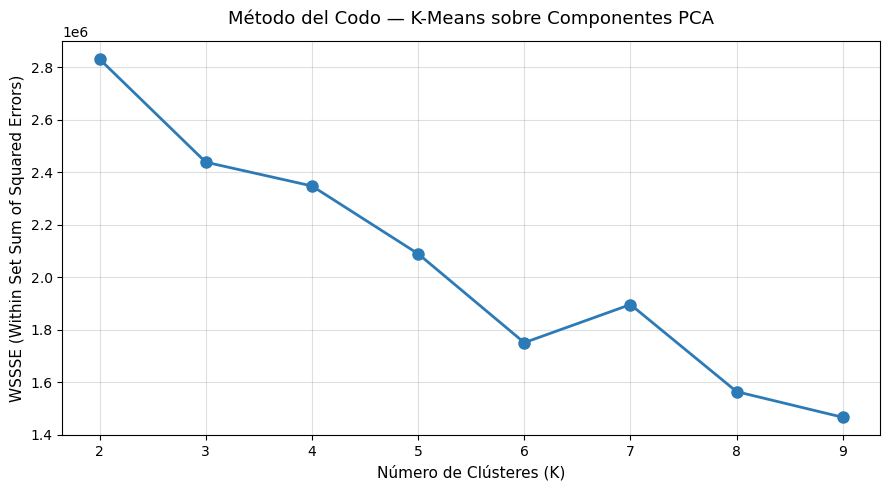

Gráfico guardado como graficos/kmeans_codo.png


In [ ]:
# ============================================================
# Gráfico del método del codo
# ============================================================
plt.figure(figsize=(9, 5))
plt.plot(list(rango_k), costos, marker="o", color="#2c7bb6", linewidth=2, markersize=8)
plt.title("Método del Codo — K-Means sobre Componentes PCA", fontsize=13, pad=12)
plt.xlabel("Número de Clústeres (K)", fontsize=11)
plt.ylabel("WSSSE (Within Set Sum of Squared Errors)", fontsize=11)
plt.xticks(list(rango_k))
plt.grid(alpha=0.4)
plt.tight_layout()
plt.savefig("graficos/kmeans_codo.png", dpi=300, bbox_inches="tight")
plt.show()
print("Gráfico guardado como graficos/kmeans_codo.png")

**Decisión de K:** El gráfico del codo muestra la caída más pronunciada entre K=5 y K=6, seguida de un repunte en K=7. Esto indica que K=6 es el punto de inflexión donde agregar más clústeres no reduce significativamente el WSSSE. Se elige **K=6** como número óptimo de clústeres.

In [ ]:
# ============================================================
# Aplicar K-Means final con el K elegido
# ============================================================
K_ELEGIDO = 6  

kmeans_final = KMeans(
    featuresCol="pca_features",
    predictionCol="cluster",
    k=K_ELEGIDO,
    seed=42,
    maxIter=30
)
modelo_kmeans = kmeans_final.fit(df_pca)
df_cluster    = modelo_kmeans.transform(df_pca)

print(f"K-Means final ajustado con K={K_ELEGIDO}")
print(f"   WSSSE final: {modelo_kmeans.summary.trainingCost:,.2f}")

# Distribución de registros por clúster
print("\n--- Distribución de registros por clúster ---")
df_cluster.groupBy("cluster").count().orderBy("cluster").show()

K-Means final ajustado con K=6
   WSSSE final: 1,750,465.49

--- Distribución de registros por clúster ---
+-------+-----+
|cluster|count|
+-------+-----+
|      0|34402|
|      1|13029|
|      2|37264|
|      3|45603|
|      4|41057|
|      5|27791|
+-------+-----+



### Tarea 12 · Interpretación de los clústeres

Para interpretar qué caracteriza a cada clúster en el dominio de la accidentalidad vial, cruzamos la asignación de clúster con las variables originales más relevantes.

In [ ]:
# ============================================================
# Perfil de cada clúster: promedios de variables numéricas
# ============================================================
print("--- Perfil numérico por clúster ---")
df_cluster.groupBy("cluster").agg(
    F.round(F.avg("HORA"), 2).alias("Hora_Prom"),
    F.round(F.avg("MES"), 2).alias("Mes_Prom"),
    F.round(F.avg("ANO_OCURRENCIA_ACC"), 2).alias("Año_Prom"),
    F.round(F.avg("LATITUD"), 4).alias("Lat_Prom"),
    F.round(F.avg("LONGITUD"), 4).alias("Lon_Prom")
).orderBy("cluster").show()

--- Perfil numérico por clúster ---
+-------+---------+--------+--------+--------+--------+
|cluster|Hora_Prom|Mes_Prom|Año_Prom|Lat_Prom|Lon_Prom|
+-------+---------+--------+--------+--------+--------+
|      0|     7.52|    6.48| 2017.71|  4.6562|-74.1011|
|      1|    12.87|    6.55| 2017.86|  4.6177|-74.1117|
|      2|    12.43|    6.54| 2017.95|  4.6116|-74.1378|
|      3|    12.62|    6.51| 2017.65|  4.6877|-74.0739|
|      4|    17.91|    6.51| 2017.81|  4.6545| -74.102|
|      5|    13.37|    6.44| 2017.63|  4.6342|-74.1118|
+-------+---------+--------+--------+--------+--------+



In [ ]:
# ============================================================
# Gravedad predominante por clúster
# Nos permite ver si los clústeres capturan distintos niveles de riesgo
# ============================================================
print("--- Distribución de GRAVEDAD por clúster ---")
df_cluster.groupBy("cluster", "GRAVEDAD").count() \
    .orderBy("cluster", F.desc("count")).show(20)

# Clase de accidente predominante por clúster
print("--- Clase de accidente más frecuente por clúster ---")
df_cluster.groupBy("cluster", "CLASE_ACC").count() \
    .orderBy("cluster", F.desc("count")).show(20)

# Franja horaria predominante por clúster
print("--- Franja horaria predominante por clúster ---")
df_cluster.groupBy("cluster", "FRANJA_HORARIA").count() \
    .orderBy("cluster", F.desc("count")).show(15)

--- Distribución de GRAVEDAD por clúster ---
+-------+-----------+-----+
|cluster|   GRAVEDAD|count|
+-------+-----------+-----+
|      0| SOLO DANOS|24302|
|      0|CON HERIDOS| 9850|
|      0|CON MUERTOS|  250|
|      1| SOLO DANOS| 9121|
|      1|CON HERIDOS| 3777|
|      1|CON MUERTOS|  131|
|      2| SOLO DANOS|26444|
|      2|CON HERIDOS|10337|
|      2|CON MUERTOS|  483|
|      3| SOLO DANOS|36700|
|      3|CON HERIDOS| 8586|
|      3|CON MUERTOS|  317|
|      4| SOLO DANOS|31053|
|      4|CON HERIDOS| 9703|
|      4|CON MUERTOS|  301|
|      5|CON HERIDOS|25447|
|      5|CON MUERTOS| 1757|
|      5| SOLO DANOS|  587|
+-------+-----------+-----+

--- Clase de accidente más frecuente por clúster ---
+-------+-----------------+-----+
|cluster|        CLASE_ACC|count|
+-------+-----------------+-----+
|      0|           CHOQUE|34402|
|      1|           CHOQUE|12476|
|      1|CAIDA DE OCUPANTE|  275|
|      1|      VOLCAMIENTO|  222|
|      1|             OTRO|   56|
|      2|    

**Interpretación de los clústeres (K=6):**

- **Clúster 0 (34,402 accidentes — 17.3%):** Exclusivamente CHOQUES ocurridos en HORA PICO MAÑANA (7:52 hora promedio).Lat: 4.66, Lon: -74.10. Representa los choques del tráfico matutino con 70.6% SOLO DANOS.

- **Clúster 1 (13,029 accidentes — 6.6%):** El clúster más pequeño. CHOQUES en HORA VALLE con mezcla de CAIDA DE OCUPANTE y VOLCAMIENTO.Lat: 4.62, Lon: -74.11. Mayor proporción relativa de CON MUERTOS (1.01%).

- **Clúster 2 (37,264 accidentes — 18.8%):** Exclusivamente CHOQUES en HORA VALLE.Lat: 4.61, Lon: -74.14. 27.7% CON HERIDOS y mayor proporción de CON MUERTOS (1.30%) que los clústeres de hora pico.

- **Clúster 3 (45,603 accidentes — 23.0%):** El clúster más grande. Exclusivamente CHOQUES en HORA VALLE.Lat: 4.69, Lon: -74.07. Perfil de menor riesgo: 80.5% SOLO DANOS y solo 0.69% CON MUERTOS.

- **Clúster 4 (41,057 accidentes — 20.7%):** Exclusivamente CHOQUES en HORA PICO TARDE (17:91 hora promedio).Lat: 4.65, Lon: -74.10. Representa los choques del tráfico vespertino con 75.6% SOLO DANOS.

- **Clúster 5 (27,791 accidentes — 14.0%):** El clúster de mayor riesgo. Dominado por ATROPELLOS (20,138), CAIDA DE OCUPANTE (4,364) y VOLCAMIENTO (2,507). Solo 2.1% SOLO DANOS vs 91.6% CON HERIDOS. Concentra 1,757 de los 2,239 accidentes CON MUERTOS del dataset (78.5%). Zona centro-sur en HORA VALLE y HORA PICO TARDE.

## PARTE C · Clasificación supervisada

### Tarea 13 · Variable objetivo y justificación

La variable objetivo es **`GRAVEDAD`**, con tres clases ordenadas por severidad:
- `0` → SOLO DANOS (daños materiales, sin víctimas)
- `1` → CON HERIDOS (al menos una persona lesionada)
- `2` → CON MUERTOS (al menos un fallecido)

**Justificación analítica:** Predecir la gravedad de un accidente desde variables contextuales (hora, localidad, tipo de accidente) tiene aplicación directa en la priorización de recursos de emergencia y en políticas de prevención vial focalizadas.

**Nota sobre el desbalance:** La clase CON MUERTOS representa ~2% del dataset. Esto afectará principalmente el recall de esa clase; lo reportaremos explícitamente en las métricas.

### Tarea 14 · División train/test 80-20 con semilla fija

In [19]:
# Semilla fija para reproducibilidad
MI_SEMILLA = 3463

# Usamos df_prep (con label + features_scaled) para los modelos de clasificación
df_modelo = df_prep.select("label", "features_scaled", "GRAVEDAD", "CLASE_ACC", "LOCALIDAD", "FRANJA_HORARIA")

df_train, df_test = df_modelo.randomSplit([0.8, 0.2], seed=MI_SEMILLA)

print(f"División completada con semilla fija = {MI_SEMILLA}")
print(f"   Train: {df_train.count():,} registros")
print(f"   Test : {df_test.count():,} registros")

# Verificar que la distribución de clases se preserva en ambas particiones
total_train = df_train.count()
total_test  = df_test.count()
print("\n--- Distribución de GRAVEDAD en TRAIN ---")
df_train.groupBy("GRAVEDAD").count() \
    .withColumn("%", F.round(col("count") / total_train * 100, 2)) \
    .orderBy(F.desc("count")).show()
print("--- Distribución de GRAVEDAD en TEST ---")
df_test.groupBy("GRAVEDAD").count() \
    .withColumn("%", F.round(col("count") / total_test * 100, 2)) \
    .orderBy(F.desc("count")).show()

División completada con semilla fija = 3463
   Train: 159,384 registros
   Test : 39,762 registros

--- Distribución de GRAVEDAD en TRAIN ---
+-----------+------+-----+
|   GRAVEDAD| count|    %|
+-----------+------+-----+
| SOLO DANOS|102629|64.39|
|CON HERIDOS| 54139|33.97|
|CON MUERTOS|  2616| 1.64|
+-----------+------+-----+

--- Distribución de GRAVEDAD en TEST ---
+-----------+-----+-----+
|   GRAVEDAD|count|    %|
+-----------+-----+-----+
| SOLO DANOS|25578|64.33|
|CON HERIDOS|13561|34.11|
|CON MUERTOS|  623| 1.57|
+-----------+-----+-----+



### Balanceo por weightCol
Se asignan pesos inversamente proporcionales a la frecuencia de cada clase para que el modelo no ignore CON MUERTOS (~2% del dataset). El df_test no se modifica — los pesos solo aplican al entrenamiento.

In [20]:
df_solo_danos   = df_train.filter(col("label") == 0)
df_con_heridos  = df_train.filter(col("label") == 1)
df_con_muertos  = df_train.filter(col("label") == 2)
# Calcular peso inversamente proporcional a la frecuencia de cada clase
total_train = df_train.count()
conteos = df_train.groupBy("label").count()

df_pesos = conteos.withColumn(
    "weight",
    F.round(total_train / (3 * col("count")), 4)
)

# Unir los pesos al df_train
df_train_w = df_train.join(df_pesos.select("label", "weight"), on="label", how="left")

print("--- Pesos asignados por clase ---")
df_pesos.orderBy("label").show()

--- Pesos asignados por clase ---
+-----+------+-------+
|label| count| weight|
+-----+------+-------+
|  0.0|102629| 0.5177|
|  1.0| 54139| 0.9813|
|  2.0|  2616|20.3089|
+-----+------+-------+



### Función auxiliar de métricas

Función reutilizable que calcula accuracy, precision, recall, F1 y AUC para clasificación multiclase, y muestra la matriz de confusión.

In [21]:
# ============================================================
# FUNCIÓN AUXILIAR DE MÉTRICAS — multiclase
# Calcula accuracy, precision, recall, F1 y AUC
# Imprime la matriz de confusión con crosstab
# ============================================================
def evaluar_modelo(predictions, nombre_modelo):
    evaluador_mc = MulticlassClassificationEvaluator(
        labelCol="label",
        predictionCol="prediction"
    )
    evaluador_bin = BinaryClassificationEvaluator(
        labelCol="label",
        rawPredictionCol="rawPrediction",
        metricName="areaUnderROC"
    )

    accuracy  = evaluador_mc.evaluate(predictions, {evaluador_mc.metricName: "accuracy"})
    precision = evaluador_mc.evaluate(predictions, {evaluador_mc.metricName: "weightedPrecision"})
    recall    = evaluador_mc.evaluate(predictions, {evaluador_mc.metricName: "weightedRecall"})
    f1        = evaluador_mc.evaluate(predictions, {evaluador_mc.metricName: "f1"})

    # AUC solo aplica bien en binario; para multiclase lo reportamos como referencia
    try:
        auc = evaluador_bin.evaluate(predictions)
    except Exception:
        auc = float("nan")

    print(f"\n{'='*52}")
    print(f"  MÉTRICAS — {nombre_modelo}")
    print(f"{'='*52}")
    print(f"  Accuracy           : {accuracy:.4f}")
    print(f"  Precision (pond.)  : {precision:.4f}")
    print(f"  Recall    (pond.)  : {recall:.4f}")
    print(f"  F1-Score  (pond.)  : {f1:.4f}")
    print(f"  AUC-ROC            : {auc:.4f}")
    print(f"{'='*52}")

    print(f"\n--- Matriz de Confusión — {nombre_modelo} ---")
    predictions.crosstab("GRAVEDAD", "prediction").show()

    return {
        "modelo": nombre_modelo,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "auc": auc
    }

print("Función evaluar_modelo definida.")

Función evaluar_modelo definida.


### Tarea 15 · Modelo 1 — Regresión Logística

In [22]:
mapa_clases = {0.0: "SOLO DANOS", 1.0: "CON HERIDOS", 2.0: "CON MUERTOS"}
orden = ["SOLO DANOS", "CON HERIDOS", "CON MUERTOS"]

In [23]:
# ============================================================
# REGRESIÓN LOGÍSTICA (Baseline)
# family="multinomial" porque GRAVEDAD tiene 3 clases
# regParam=0.01: regularización L2 leve para evitar overfitting
# maxIter=20: suficiente para convergencia en este dataset
# ============================================================
lr = LogisticRegression(
    labelCol="label",
    featuresCol="features_scaled",
    weightCol="weight",       
    family="multinomial",
    maxIter=20,
    regParam=0.01,
    elasticNetParam=0.0
)
modelo_lr = lr.fit(df_train_w)   
pred_lr   = modelo_lr.transform(df_test)

metricas_lr = evaluar_modelo(pred_lr, "Regresión Logística")


  MÉTRICAS — Regresión Logística
  Accuracy           : 0.6403
  Precision (pond.)  : 0.6747
  Recall    (pond.)  : 0.6403
  F1-Score  (pond.)  : 0.6285
  AUC-ROC            : nan

--- Matriz de Confusión — Regresión Logística ---
+-------------------+-----+----+----+
|GRAVEDAD_prediction|  0.0| 1.0| 2.0|
+-------------------+-----+----+----+
|        CON MUERTOS|  207|  67| 349|
|         SOLO DANOS|22380|2465| 733|
|        CON HERIDOS| 6396|2732|4433|
+-------------------+-----+----+----+



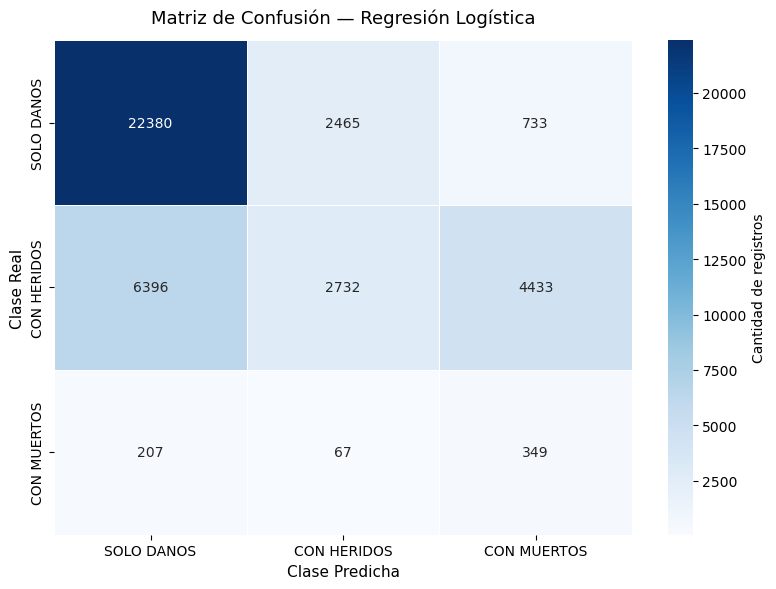

Gráfico guardado como graficos/matriz_confusion_lr.png


In [24]:
# ============================================================
# Heatmap de la matriz de confusión — Regresión Logística
# ============================================================
pd_conf_lr = pred_lr.select("GRAVEDAD", "prediction").toPandas()
pd_conf_lr["pred_label"] = pd_conf_lr["prediction"].map(mapa_clases)

matriz_lr = pd.crosstab(
    pd_conf_lr["GRAVEDAD"],
    pd_conf_lr["pred_label"],
    rownames=["Real"],
    colnames=["Predicho"]
).reindex(index=orden, columns=orden, fill_value=0)

plt.figure(figsize=(8, 6))
sns.heatmap(
    matriz_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    cbar_kws={"label": "Cantidad de registros"}
)
plt.title("Matriz de Confusión — Regresión Logística", fontsize=13, pad=12)
plt.ylabel("Clase Real", fontsize=11)
plt.xlabel("Clase Predicha", fontsize=11)
plt.tight_layout()
plt.savefig("graficos/matriz_confusion_lr.png", dpi=300, bbox_inches="tight")
plt.show()
print("Gráfico guardado como graficos/matriz_confusion_lr.png")

### Tarea 15 · Modelo 2 — Random Forest

In [25]:
# ============================================================
# RANDOM FOREST
# numTrees=100: cantidad estándar que balancea rendimiento y costo
# maxDepth=10: profundidad suficiente para capturar patrones no lineales
# seed=MI_SEMILLA: garantiza reproducibilidad
# ============================================================
rf = RandomForestClassifier(
    labelCol="label",
    featuresCol="features_scaled",
    weightCol="weight",        
    numTrees=100,
    maxDepth=10,
    seed=MI_SEMILLA
)
modelo_rf = rf.fit(df_train_w)   
pred_rf   = modelo_rf.transform(df_test)

metricas_rf = evaluar_modelo(pred_rf, "Random Forest")


  MÉTRICAS — Random Forest
  Accuracy           : 0.6746
  Precision (pond.)  : 0.7538
  Recall    (pond.)  : 0.6746
  F1-Score  (pond.)  : 0.6425
  AUC-ROC            : nan

--- Matriz de Confusión — Random Forest ---
+-------------------+-----+----+----+
|GRAVEDAD_prediction|  0.0| 1.0| 2.0|
+-------------------+-----+----+----+
|        CON MUERTOS|  231|  69| 323|
|         SOLO DANOS|24081| 655| 842|
|        CON HERIDOS| 7279|2418|3864|
+-------------------+-----+----+----+



### Tarea 16 · Comparación de métricas entre modelos

In [26]:
# ============================================================
# Tabla comparativa de métricas
# ============================================================

print("\n" + "="*60)
print("  COMPARACIÓN DE MODELOS")
print("="*60)
print(f"{'Métrica':<22} {'Reg. Logística':>18} {'Random Forest':>16}")
print("-"*60)
metricas_comparar = ["accuracy", "precision", "recall", "f1", "auc"]
for metrica in metricas_comparar:
    print(f"  {metrica.capitalize():<20} {metricas_lr[metrica]:>18.4f} {metricas_rf[metrica]:>16.4f}")
print("="*60)


  COMPARACIÓN DE MODELOS
Métrica                    Reg. Logística    Random Forest
------------------------------------------------------------
  Accuracy                         0.6403           0.6746
  Precision                        0.6747           0.7538
  Recall                           0.6403           0.6746
  F1                               0.6285           0.6425
  Auc                                 nan              nan


### Tarea 17 · Análisis de la matriz de confusión

Las matrices de confusión ya fueron impresas por `evaluar_modelo`. Aquí visualizamos la del mejor modelo con un heatmap para identificar dónde se confunde más.

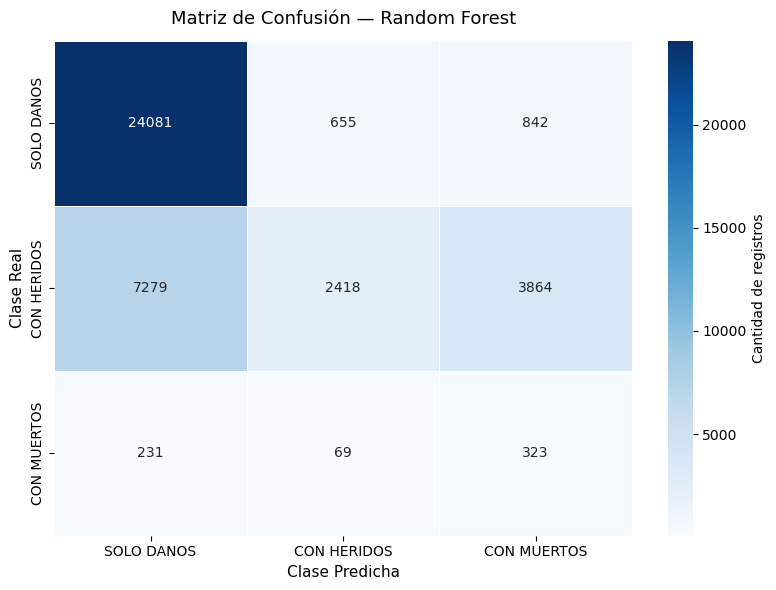

Gráfico guardado como graficos/matriz_confusion_rf.png


In [27]:
# ============================================================
# Heatmap de la matriz de confusión — Random Forest
# Construida manualmente para poder controlar etiquetas
# ============================================================
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Extraemos las predicciones y etiquetas reales a Pandas
pd_conf = pred_rf.select("GRAVEDAD", "prediction").toPandas()

# Mapeamos el número de predicción a la etiqueta de texto
# StringIndexer asigna 0 al más frecuente: SOLO DANOS=0, CON HERIDOS=1, CON MUERTOS=2
pd_conf["pred_label"] = pd_conf["prediction"].map(mapa_clases)

# Construir la matriz de confusión
matriz = pd.crosstab(
    pd_conf["GRAVEDAD"],
    pd_conf["pred_label"],
    rownames=["Real"],
    colnames=["Predicho"]
).reindex(index=orden, columns=orden, fill_value=0)

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    matriz,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    cbar_kws={"label": "Cantidad de registros"}
)
plt.title("Matriz de Confusión — Random Forest", fontsize=13, pad=12)
plt.ylabel("Clase Real", fontsize=11)
plt.xlabel("Clase Predicha", fontsize=11)
plt.tight_layout()
plt.savefig("graficos/matriz_confusion_rf.png", dpi=300, bbox_inches="tight")
plt.show()
print("Gráfico guardado como graficos/matriz_confusion_rf.png")

### Tarea 18 · Importancia de variables — Random Forest

In [28]:
# ============================================================
# Feature Importance del Random Forest
# Cada valor representa cuánto contribuye esa feature a reducir
# la impureza (Gini) promedio en todos los árboles
# ============================================================

# Recuperamos los nombres de las features en el mismo orden que el VectorAssembler
# Las OHE generan múltiples columnas, les asignamos nombre genérico
nombres_features = (
    cols_numericas +
    [f"CLASE_ACC_ohe_{i}" for i in range(len(df.select("CLASE_ACC").distinct().collect()))] +
    [f"LOCALIDAD_ohe_{i}" for i in range(len(df.select("LOCALIDAD").distinct().collect()))] +
    [f"FRANJA_HORARIA_ohe_{i}" for i in range(len(df.select("FRANJA_HORARIA").distinct().collect()))]
)

importancias = modelo_rf.featureImportances.toArray()

# Crear DataFrame pandas con importancias
# Ajustamos la longitud por si OHE tiene menos columnas de las esperadas
n = min(len(nombres_features), len(importancias))
df_importancia = pd.DataFrame({
    "Feature": nombres_features[:n],
    "Importancia": importancias[:n]
}).sort_values("Importancia", ascending=False)

print("--- Top 15 variables más importantes (Random Forest) ---")
print(df_importancia.head(15).to_string(index=False))

--- Top 15 variables más importantes (Random Forest) ---
             Feature  Importancia
     CLASE_ACC_ohe_0     0.358539
     CLASE_ACC_ohe_1     0.195658
                HORA     0.082726
             LATITUD     0.059021
     CLASE_ACC_ohe_2     0.056463
            LONGITUD     0.055234
     CLASE_ACC_ohe_3     0.039920
                 DIA     0.032280
  ANO_OCURRENCIA_ACC     0.024061
                 MES     0.024003
     LOCALIDAD_ohe_3     0.008028
FRANJA_HORARIA_ohe_1     0.006041
     CLASE_ACC_ohe_4     0.005457
    LOCALIDAD_ohe_11     0.004642
     LOCALIDAD_ohe_7     0.004449


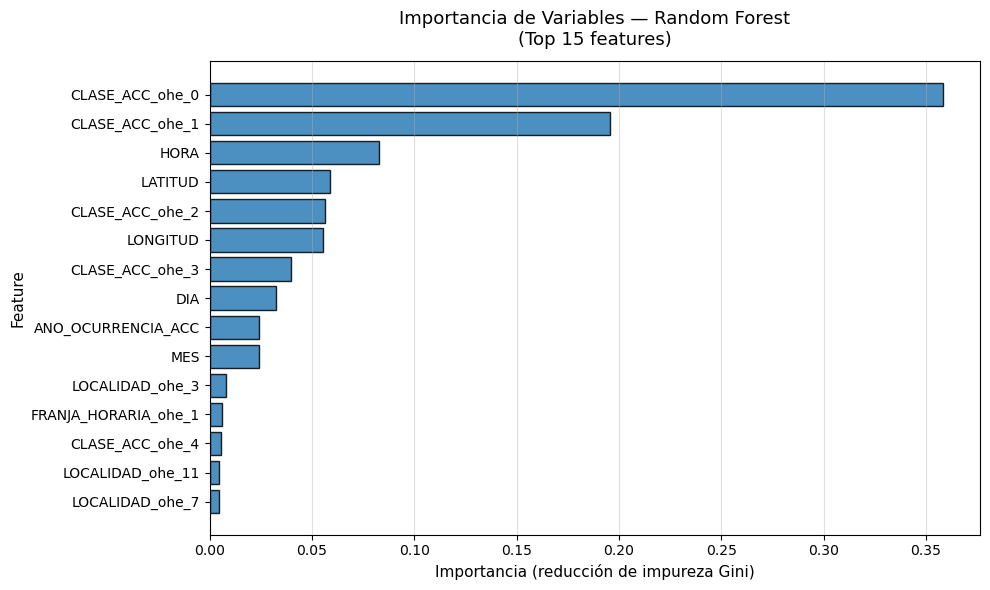

Gráfico guardado como graficos/feature_importance_rf.png


In [29]:
# ============================================================
# Gráfico de importancia de variables (top 15)
# ============================================================

top15 = df_importancia.head(15)

plt.figure(figsize=(10, 6))
plt.barh(
    top15["Feature"][::-1],
    top15["Importancia"][::-1],
    color="#2c7bb6",
    alpha=0.85,
    edgecolor="black"
)
plt.title("Importancia de Variables — Random Forest\n(Top 15 features)", fontsize=13, pad=12)
plt.xlabel("Importancia (reducción de impureza Gini)", fontsize=11)
plt.ylabel("Feature", fontsize=11)
plt.grid(axis="x", alpha=0.4)
plt.tight_layout()
plt.savefig("graficos/feature_importance_rf.png", dpi=300, bbox_inches="tight")
plt.show()
print("Gráfico guardado como graficos/feature_importance_rf.png")

## PARTE D · Validación cruzada

### Tareas 19 y 20 · CrossValidator sobre Random Forest con dos hiperparámetros

Aplicamos validación cruzada (5-fold) sobre el Random Forest, explorando dos hiperparámetros:
- **`numTrees`**: número de árboles en el ensemble (50, 100)
- **`maxDepth`**: profundidad máxima de cada árbol (5, 10)

La métrica de optimización es **F1 ponderado**, que es la más robusta para clases desbalanceadas.

In [30]:
# ============================================================
# VALIDACIÓN CRUZADA — Random Forest con ParamGrid
# ============================================================
rf_cv = RandomForestClassifier(
    labelCol="label",
    featuresCol="features_scaled",
    weightCol="weight",        # ← línea nueva
    seed=MI_SEMILLA
)

# Grid de hiperparámetros: 2 x 2 = 4 combinaciones × 5 folds = 20 entrenamientos
param_grid = ParamGridBuilder() \
    .addGrid(rf_cv.numTrees, [50, 100]) \
    .addGrid(rf_cv.maxDepth, [5, 10]) \
    .build()

# Evaluador: F1 ponderado (robusto frente al desbalance de clases)
evaluador_cv = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
)

# CrossValidator con 5 folds
cv = CrossValidator(
    estimator=rf_cv,
    estimatorParamMaps=param_grid,
    evaluator=evaluador_cv,
    numFolds=5,
    seed=MI_SEMILLA
)

print("Ejecutando validación cruzada (4 combinaciones × 5 folds = 20 entrenamientos)...")
modelo_cv = cv.fit(df_train_w)
pred_cv    = modelo_cv.transform(df_test)
print("Validación cruzada completada.")

Ejecutando validación cruzada (4 combinaciones × 5 folds = 20 entrenamientos)...
Validación cruzada completada.


In [31]:
# ============================================================
# Reportar el modelo ganador y sus parámetros óptimos
# ============================================================
mejor_modelo = modelo_cv.bestModel

print("\n" + "="*52)
print("  MODELO GANADOR — Validación Cruzada")
print("="*52)
print(f"  numTrees (óptimo) : {mejor_modelo.getNumTrees}")
print(f"  maxDepth (óptimo) : {mejor_modelo.getOrDefault('maxDepth')}")
print("="*52)

# Reportar métricas del modelo ganador sobre el conjunto de test
metricas_cv = evaluar_modelo(pred_cv, "Random Forest (CV Óptimo)")

# Comparación final: modelo base vs modelo con CV
print("\n" + "="*60)
print("  COMPARACIÓN FINAL: RF Base vs RF con Cross-Validation")
print("="*60)
print(f"{'Métrica':<22} {'RF Base':>16} {'RF con CV':>16}")
print("-"*60)
for metrica in ["accuracy", "precision", "recall", "f1"]:
    print(f"  {metrica.capitalize():<20} {metricas_rf[metrica]:>16.4f} {metricas_cv[metrica]:>16.4f}")
print("="*60)


  MODELO GANADOR — Validación Cruzada
  numTrees (óptimo) : 50
  maxDepth (óptimo) : 10

  MÉTRICAS — Random Forest (CV Óptimo)
  Accuracy           : 0.6792
  Precision (pond.)  : 0.7454
  Recall    (pond.)  : 0.6792
  F1-Score  (pond.)  : 0.6469
  AUC-ROC            : nan

--- Matriz de Confusión — Random Forest (CV Óptimo) ---
+-------------------+-----+----+----+
|GRAVEDAD_prediction|  0.0| 1.0| 2.0|
+-------------------+-----+----+----+
|        CON MUERTOS|  235|  72| 316|
|         SOLO DANOS|24144| 804| 630|
|        CON HERIDOS| 7281|2548|3732|
+-------------------+-----+----+----+


  COMPARACIÓN FINAL: RF Base vs RF con Cross-Validation
Métrica                         RF Base        RF con CV
------------------------------------------------------------
  Accuracy                       0.6746           0.6792
  Precision                      0.7538           0.7454
  Recall                         0.6746           0.6792
  F1                             0.6425           0.64

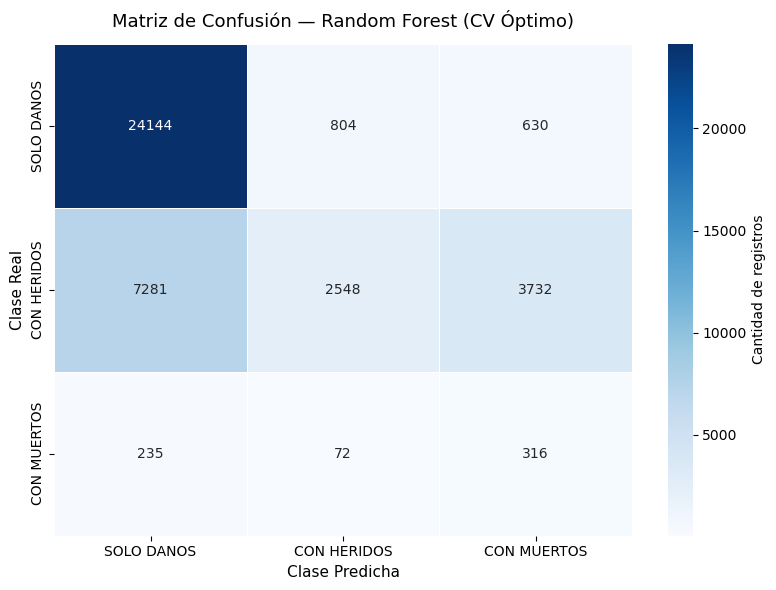

Gráfico guardado como graficos/matriz_confusion_cv.png


In [32]:
# ============================================================
# Heatmap de la matriz de confusión — Random Forest (CV Óptimo)
# ============================================================
pd_conf_cv = pred_cv.select("GRAVEDAD", "prediction").toPandas()
pd_conf_cv["pred_label"] = pd_conf_cv["prediction"].map(mapa_clases)

matriz_cv = pd.crosstab(
    pd_conf_cv["GRAVEDAD"],
    pd_conf_cv["pred_label"],
    rownames=["Real"],
    colnames=["Predicho"]
).reindex(index=orden, columns=orden, fill_value=0)

plt.figure(figsize=(8, 6))
sns.heatmap(
    matriz_cv,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    cbar_kws={"label": "Cantidad de registros"}
)
plt.title("Matriz de Confusión — Random Forest (CV Óptimo)", fontsize=13, pad=12)
plt.ylabel("Clase Real", fontsize=11)
plt.xlabel("Clase Predicha", fontsize=11)
plt.tight_layout()
plt.savefig("graficos/matriz_confusion_cv.png", dpi=300, bbox_inches="tight")
plt.show()
print("Gráfico guardado como graficos/matriz_confusion_cv.png")

In [33]:
# ============================================================
# Guardar el modelo Random Forest (CV Óptimo — mejor modelo)
# ============================================================

modelo_cv.bestModel.write().overwrite().save("modelos/modelo_randomforest")
print("Modelo guardado en modelos/modelo_randomforest")

Modelo guardado en modelos/modelo_randomforest


## Conclusiones del Bloque 2

**Conclusion 1 — No supervisado (PCA + K-Means):**
Con 10 componentes principales se explica el 40.96% de la varianza del dataset de accidentalidad. Se adopto un umbral del 40% como criterio pragmatico dado que la varianza se distribuye de forma uniforme entre componentes (máximo 7.05% por componente), lo que hace inviable alcanzar el estandar del 80% sin perder la ventaja de reduccion dimensional. El K-Means con K=6 (WSSSE=1,750,465) revelo grupos con perfiles de riesgo muy distintos. El Cluster 5 (27,791 accidentes) es el mas peligroso: es el unico dominado por atropellos en lugar de choques, concentra el 91.6% de sus accidentes en CON HERIDOS y acumula 1,757 de los 2,239 accidentes mortales del dataset completo (78.5%). En contraste, el Clúster 3 (45,603 accidentes) es el de menor riesgo con 80.5% SOLO DANOS y apenas 0.69% CON MUERTOS, compuesto exclusivamente por choques en hora valle en la zona nororiental.

**Conclusion 2 — Clasificacion supervisada:** 
El Random Forest supero a la Regresion Logistica en todas las metricas (F1: 0.6425 vs 0.6285, Accuracy: 0.6746 vs 0.6403). La clase mas dificil de predecir fue CON HERIDOS: 7,279 de 13,561 casos reales fueron clasificados incorrectamente como SOLO DANOS (53.7% de error). Esto refleja un limite informativo del dataset — variables determinantes de la gravedad real como velocidad del vehiculo, uso de casco o cinturon y tipo de via no estan disponibles. La variable mas importante para la prediccion fue CLASE_ACC (importancia acumulada de sus categorias OHE: 0.656), seguida de HORA (0.083) y LATITUD (0.059).

**Conclusion 3 — Validacion cruzada:**
La validacion cruzada con 5 folds identifico como configuracion optima numTrees=50 y maxDepth=10, mejorando el F1 de 0.6425 a 0.6469 y la accuracy de 0.6746 a 0.6792 respecto al RF base. La mejora es modesta pero consistente, lo que sugiere que el limite del modelo no es de hiperparametros sino de informacion disponible en las features. Para mejorar significativamente la prediccion de gravedad se requeriría enriquecer el dataset con variables de infraestructura vial y comportamiento del conductor.